In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from astropy.io import fits
import matplotlib.cm as cm
import matplotlib.patches as patches
import matplotlib as mpl
from uncertainties import ufloat
from uncertainties.umath import *
from uncertainties import unumpy
from mpl_toolkits.axes_grid1 import make_axes_locatable

font = {'size'   : 8}
mpl.rc('font', **font)
minorLocator = MultipleLocator(10)

AUtoCM = 1.496e13 # 1 AU = 1.496e13 cm
PCtoCM = 3.086e18 # 1 pc = 3.09e18 cm
h = 6.626e-27 #planck's constant in cm2 g s-1
k = 1.381e-16 #Boltzmann's constant in cm2 g s-2 K-1
c = 2.998e10 #light speed in cm s-1
mmw = 2.86 #mean molecular weight, (Kirk et al. 2013; Pattle et al. 2015) 
Hm = 1.674e-24 #HI mass in g

freq = 2.30538e2 #CO 2-1 freq. in GHz
bmaj = 1.36818736792e-04 * 3600 #major beam in arcsec
bmin = 9.05337437871e-05 * 3600 #minor beamin arcsec
chan_vel = 3.175 #channel velocity width in km/s
E_u = 16.59608 #upper level energy of CO 2-1 in Kelvin
Aij = 10**-6.16 #CO 2-1 A coefficient in s-1
B0 = 57635.968 #in MHz CO rotational constant https://physics.nist.gov/PhysRefData/MolSpec/Diatomic/Html/Tables/CO.html
co2H2 = 1e-4 #CO to H2 ratio, Dickman 1978
J = 2 #upper rotation level

### IAS4A outflow paras ###
dist = 300 #in pc
v0 = 4.8 #in km s-1 arcsec-1, 15.6*np.sin(18.1*np.pi/180) from pv_red_2fits1v2c1incl_6.86 
delta_vlos = 0.8 #turbulent linewidth, in km/s
Tex = 70 #in Kelvin

indi = 1 #index interval
indy = 0 #index start in y
indx = 0 #index start in x
levs0 = 5. #from chapolmap_P_241022
rms = 0.0048 #from chapolmap_P_241022

#####
d1 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/red.i.cm.fits")
data1 = d1[0].data
data2 = data1.squeeze()
d1.close() 

red_tmp = data2[22-1,6::8,1::8]
dx = 0
dy = 1
red= red_tmp[56-13+dx:56+13+dx,56-13+dy:56+13+dy] #find dx dy with compare the index of an element in pa1 and red 
#####

d1 = fits.open('/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3/imbin_x5y3/red.i22.fits')
data1 = d1[0].data
data2 = data1.squeeze()
header1 = d1[0].header
naxis1 = header1['NAXIS1']
crpix1 = header1['CRPIX1']
naxis2 = header1['NAXIS2']
crpix2 = header1['CRPIX2']
ps = header1['CDELT2']*3600 #pixel size in arcsec
X_bin,Y_bin = np.meshgrid( np.arange(0,naxis1,1)-crpix1+1,np.arange(0,naxis2,1)-crpix2+1)
#+1 because header count from 1, but python array count from 0
r_bin = np.sqrt(X_bin**2+Y_bin**2)*ps
#print(repr(header1))
d1.close() 
i1 = data2[indy::indi,indx::indi]
i1[red < levs0*rms] = np.nan

T1 = 1.222e3 * (i1*1000)/(freq**2*bmaj*bmin) #from Jy/beam to Kelvin
Qrot = k*Tex/(h*B0*1e6) + 1./3. #Eq 52 in Mangum & Shirley 2015
N1 = 8*np.pi*(freq*1e9)**2*k/(Aij*h*c**3)*Qrot/(2*J+1)*np.exp(E_u/Tex)*T1*(chan_vel*1e5)
#column density of total CO transitions in cm-2, Eq 82 in Mangum & Shirley 2015, Eq 1 in Goldsmith 1997
chan_z = chan_vel/v0*dist*AUtoCM #the line-of-sight depth of each channel in cm
n1 = N1/co2H2/chan_z #H2 number density in cm-3
rho1 = n1*mmw*Hm #density in g/cm-3

d1 = fits.open('/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3/imbin_x5y3/red.pa22.fits')
data1 = d1[0].data
data1[:,r_bin > 25.3/3/2] = np.nan #mask data outside 2/3 FOV
data2 = data1.squeeze()
d1.close() 
pa1 = data2[indy::indi,indx::indi]*np.pi/180 
pa1[red < levs0*rms] = np.nan #mask data under 5 sigma

d1 = fits.open('/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3/imbin_x5y3/red.paerr22.fits')
data1 = d1[0].data
data1[:,r_bin > 25.3/3/2] = np.nan 
data2 = data1.squeeze()
d1.close() 
paerr = data2[indy::indi,indx::indi]*np.pi/180
paerr[red < levs0*rms] = np.nan

pa2 = unumpy.uarray(pa1,paerr)
pa1_std = np.empty([len(pa1),len(pa1[0])]) 
pa1_std[:] = np.nan
pa1_std_u = unumpy.uarray(pa1,paerr)
pa1_std_u[:] = np.nan
        
for xx in range(1, len(pa1[0])-1):
    for yy in range(1, len(pa1)-1):
        tmp = pa2[yy-1:yy+2,xx-1:xx+2]
        tmp2 = pa1[yy-1:yy+2,xx-1:xx+2]
        tmp3 = paerr[yy-1:yy+2,xx-1:xx+2]
        weights = 1/(tmp3[~np.isnan(tmp3)]**2)
        data = tmp2[~np.isnan(tmp2)]
        if (9-np.count_nonzero(np.isnan(tmp2)) > 3):
            weighted_average = np.average(data, weights=weights)
            weighted_variance = np.average((data - weighted_average)**2, weights=weights)
            weighted_std = np.sqrt(weighted_variance)
            pa1_std[yy,xx] = weighted_std
            data = tmp[~np.isnan(tmp2)]
            pa2_mean = np.average(data, weights=weights)
            pa2_var = np.average((data - pa2_mean)**2, weights=weights)
            pa1_std_u[yy,xx] = sqrt(pa2_var)

##add 250221 to calculate distance#
#4a1: 03 29 10.529 31 13 31.05 #from Reipurth 2002
xyshift = 1.3 #find the value by fit figures
ra=np.array([3,29,10.529])
dec=np.array([31,13,31.05])
dec1_deg=dec[0]+dec[1]/60+dec[2]/3600
ra1_deg=(ra[0]+ra[1]/60+ra[2]/3600)*15
ra0_deg = header1['CRVAL1']
dec0_deg = header1['CRVAL2']
dec1_pix_offset = header1['CRPIX2']+(dec1_deg-dec0_deg)*3600/ps -xyshift+0.2
ra1_pix_offset = header1['CRPIX1']-(ra1_deg-ra0_deg)*3600*np.cos(dec0_deg*np.pi/180)/ps -xyshift

ra=np.array([3,29,10.421])
dec=np.array([31,13,32.21])
dec2_deg=dec[0]+dec[1]/60+dec[2]/3600
ra2_deg=(ra[0]+ra[1]/60+ra[2]/3600)*15
dec2_pix_offset = header1['CRPIX2']+(dec2_deg-dec0_deg)*3600/ps  -xyshift+0.2
ra2_pix_offset = header1['CRPIX1']-(ra2_deg-ra0_deg)*3600*np.cos(dec0_deg*np.pi/180)/ps -xyshift


In [2]:
bf = 0.5*np.sqrt(4*np.pi*rho1)/pa1_std*(delta_vlos*1e5)*1e3 #B field strength, in mG
bf[np.isnan(pa1)] = np.nan
bf[5,14] = np.nan #it is an 4A2 pol, not 4A1 pol
bf_u = 0.5*np.sqrt(4*np.pi*rho1)/pa1_std_u*(delta_vlos*1e5)*1e3 #B field strength uncertainty, in mG
bf_u[np.isnan(pa1)] = np.nan

Px=np.sin(pa1)
Py=np.cos(pa1)
Bx=np.sin(pa1)*bf
By=np.cos(pa1)*bf
Bx_u = unumpy.uarray(pa1,paerr)
Bx_u[:] = np.nan
By_u = unumpy.uarray(pa1,paerr)
By_u[:] = np.nan

for xx in range(1, len(pa1[0])-1):
    for yy in range(1, len(pa1)-1):
        Bx_u[yy,xx]=sin(pa2[yy,xx])*bf_u[yy,xx]
        By_u[yy,xx]=cos(pa2[yy,xx])*bf_u[yy,xx]

pixel = 0.4 #pixel size in arcsec
dBydy_2, dBydx_2 = np.gradient(By/(pixel*dist*AUtoCM)) #in unit of mG cm-1
dBxdy_2, dBxdx_2 = np.gradient(Bx/(pixel*dist*AUtoCM))
dBydy = dBydy_2 
dBxdy = dBxdy_2 
dBydx = dBydx_2*-1
dBxdx = dBxdx_2*-1
#-1 because the ra direction is opposite to the pixel direction

By_u_x0 = By_u[:,:-2] 
By_u_x2 = By_u[:,2:]
By_x0 = By[:,:-2] 
By_x2 = By[:,2:] 
dBydx_tmp = (By_x2-By_x0)/(2*pixel*dist*AUtoCM)*-1
dBydx_u = (By_u_x2-By_u_x0)/(2*pixel*dist*AUtoCM)*-1
#print(dBydx_u[~np.isnan(dBydx_tmp)])
#print(dBydx_2[~np.isnan(dBydx_2)])

By_u_y0 = By_u[:-2,:] 
By_u_y2 = By_u[2:,:]
By_y0 = By[:-2,:] 
By_y2 = By[2:,:] 
dBydy_tmp = (By_y2-By_y0)/(2*pixel*dist*AUtoCM)
dBydy_u = (By_u_y2-By_u_y0)/(2*pixel*dist*AUtoCM)
#print(dBydy_u[~np.isnan(dBydy_tmp)])
#print(dBydy_2[~np.isnan(dBydy_2)])

Bx_u_x0 = Bx_u[:,:-2] 
Bx_u_x2 = Bx_u[:,2:]
Bx_x0 = Bx[:,:-2] 
Bx_x2 = Bx[:,2:] 
dBxdx_tmp = (Bx_x2-Bx_x0)/(2*pixel*dist*AUtoCM)*-1
dBxdx_u = (Bx_u_x2-Bx_u_x0)/(2*pixel*dist*AUtoCM)*-1
#print(dBxdx_u[~np.isnan(dBxdx_tmp)])
#print(dBxdx_2[~np.isnan(dBxdx_2)])

Bx_u_y0 = Bx_u[:-2,:] 
Bx_u_y2 = Bx_u[2:,:]
Bx_y0 = Bx[:-2,:] 
Bx_y2 = Bx[2:,:] 
dBxdy_tmp = (Bx_y2-Bx_y0)/(2*pixel*dist*AUtoCM)
dBxdy_u = (Bx_u_y2-Bx_u_y0)/(2*pixel*dist*AUtoCM)
#print(dBxdy_u[~np.isnan(dBxdy_tmp)])
#print(dBxdy_2[~np.isnan(dBxdy_2)])

dBxdx[np.isnan(pa1)] = 'nan'
dBxdy[np.isnan(pa1)] = 'nan'
dBydx[np.isnan(pa1)] = 'nan'
dBydy[np.isnan(pa1)] = 'nan'

dBydx_dBxdy = (dBydx - dBxdy).flatten()
dBydx_dBxdy_u = (dBydx_u[1:-1,:] - dBxdy_u[:,1:-1]).flatten()
dBydx_dBxdy_tmp = (dBydx_tmp[1:-1,:] - dBxdy_tmp[:,1:-1]).flatten()
dBydx_dBxdy_velues = dBydx_dBxdy[~np.isnan(dBydx_dBxdy)]
dBydx_dBxdy_u_velues = dBydx_dBxdy_u[~np.isnan(dBydx_dBxdy_tmp)]

dBerr = np.empty(len(dBydx_dBxdy_velues)) 
for xx in range(0, len(dBerr)):
    dBerr[xx] = dBydx_dBxdy_u_velues[xx].std_dev

print(dBydx_dBxdy_velues)
print(dBydx_dBxdy_u_velues)
print(dBerr)


[-4.14542262e-16 -4.83003448e-18 -1.85539281e-16  4.17841104e-16
  3.55986009e-17  3.29688566e-16  5.91935048e-16  5.50441199e-17
  3.37435033e-16]
[-4.145422396414172e-16+/-1.8354382255819932e-16
 -4.830069295903687e-18+/-1.9722406997623836e-16
 -1.8553925354703476e-16+/-2.0429509422188169e-16
 4.1784110280585853e-16+/-2.079580125412026e-16
 3.559859268543606e-17+/-1.0501469152018605e-16
 3.2968860733465514e-16+/-1.831357778119599e-16
 5.919350728275934e-16+/-2.2172302194646139e-16
 5.5044135365998264e-17+/-1.4846437134156213e-16
 3.3743502103876457e-16+/-2.2892094815918944e-16
 -7.641375783374338e-16+/-1.7449497180697877e-15]
[1.83543823e-16 1.97224070e-16 2.04295094e-16 2.07958013e-16
 1.05014692e-16 1.83135778e-16 2.21723022e-16 1.48464371e-16
 2.28920948e-16]


(26, 26)
xpix= 26 ypix= 26


/var/folders/sx/1b55yzdj67g8dg8fyg5xygx00000gn/T/ipykernel_74663/1735823470.py:169: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.errorbar(i2[~np.isnan(dBydx_dBxdy)],dBydx_dBxdy_velues,yerr=dBerr, fmt='ro',c='Gray', alpha=plt_alpha, markersize=marker_size)


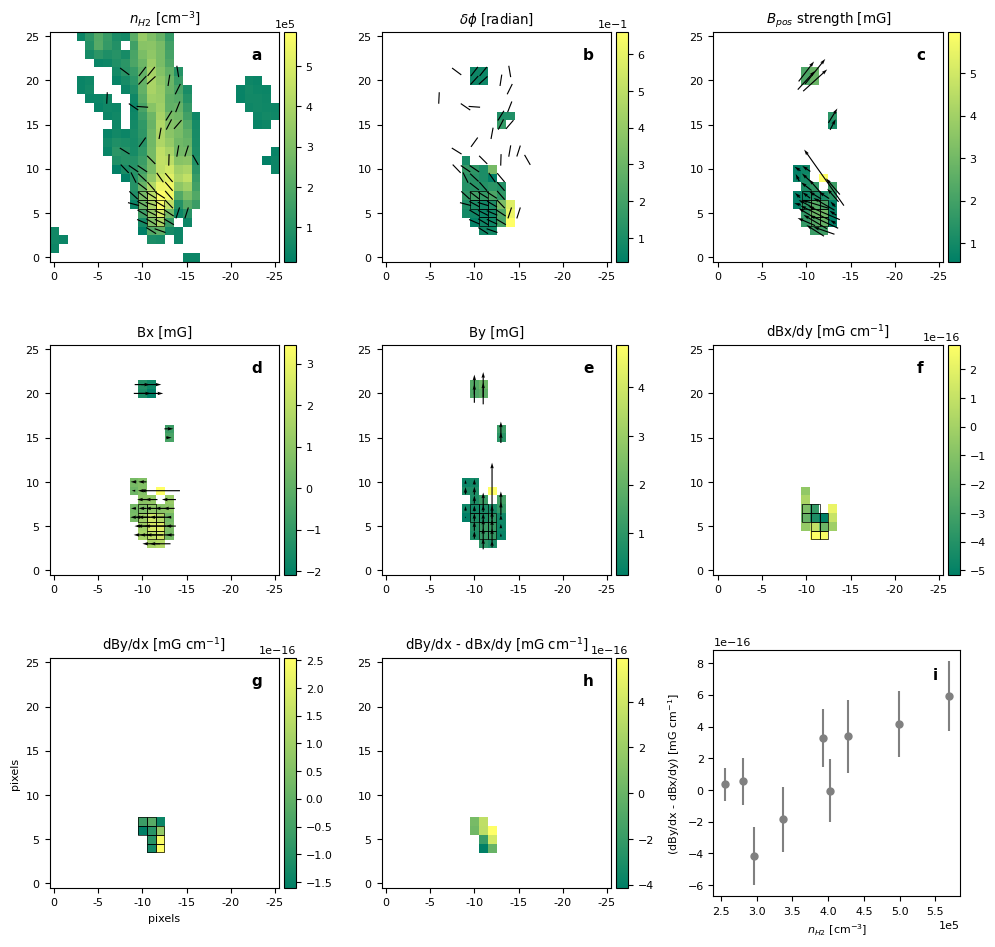

In [3]:

print(np.shape(pa1))
xpix = np.shape(pa1)[1]
ypix = np.shape(pa1)[0]
print('xpix=',xpix,'ypix=',ypix)

x = np.linspace(0.,xpix-1,xpix)
y = np.linspace(0.,ypix-1,ypix)
xv, yv = np.meshgrid(x, y)
        
fig = plt.figure(figsize=(10,10), layout='tight')
extent0=[-0.5, xpix-0.5, -0.5, ypix-0.5]
cmp0=cm.summer
sc = 20 #scale for quiver
wd = 0.005 #width for quiver

#####
new_tick_locations = np.array([0,5,10,15,20,25])

def highlight_cell(x,y, ax=None, **kwargs):
    rect = plt.Rectangle((x-.5, y-.5), 1,1, fill=False, **kwargs)
    ax = ax or plt.gca()
    ax.add_patch(rect)
    return rect

xv_1 = xv[~np.isnan(dBydx - dBxdy)]
yv_1 = yv[~np.isnan(dBydx - dBxdy)]
######

ax1 = plt.subplot(3,3,1)
ax1.set(aspect=1)
ax1.quiver(xv, yv, -1*Px, Py, color='k',scale=sc, headwidth=0, headlength=0, linewidth=0.1, width=wd, headaxislength=0, pivot='mid',edgecolor='none')
cs = plt.imshow(n1, interpolation='nearest', cmap=cmp0, extent=extent0, origin='lower')
#-1 because the ra direction is opposite to the pixel direction
plt.title(r'$n_{H2}$ [cm$^{-3}$]')
ax1.set_xticks(new_tick_locations)
ax1.set_xticklabels([0,-5,-10,-15,-20,-25])
for xx2 in range(0, len(xv_1)):
    highlight_cell(xv_1[xx2],yv_1[xx2], color="k", linewidth=0.5)

divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(cs,cax=cax)
cbar.formatter.set_powerlimits((0, 0))
cbar.update_ticks()
ax1.text(0.9,0.9, r'a',horizontalalignment='center',verticalalignment='center',transform=ax1.transAxes, fontsize=11, weight='bold')
#ax1.scatter(ra1_pix_offset,dec1_pix_offset,40, c='r', marker="+") 
#ax1.scatter(ra2_pix_offset,dec2_pix_offset,40, c='r', marker="+") 

ax1 = plt.subplot(3,3,2)
ax1.set(aspect=1)
ax1.quiver(xv, yv, -1*Px, Py, color='k',scale=sc, headwidth=0, headlength=0, linewidth=0.1, width=wd, headaxislength=0, pivot='mid',edgecolor='none')
cs = plt.imshow(pa1_std, interpolation='nearest', cmap=cmp0, extent=extent0, origin='lower')
#-1 because the ra direction is opposite to the pixel direction
plt.title(r'$\delta \phi$ [radian]')
ax1.set_xticks(new_tick_locations)
ax1.set_xticklabels([0,-5,-10,-15,-20,-25])
for xx2 in range(0, len(xv_1)):
    highlight_cell(xv_1[xx2],yv_1[xx2], color="k", linewidth=0.5)
    
divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(cs,cax=cax)
cbar.formatter.set_powerlimits((0, 0))
cbar.update_ticks()
ax1.text(0.9,0.9, r'b',horizontalalignment='center',verticalalignment='center',transform=ax1.transAxes, fontsize=11, weight='bold')

ax1 = plt.subplot(3,3,3)
ax1.set(aspect=1)
ax1.quiver(xv, yv, -1*Bx, By, color='k', \
           scale=sc, width=wd, pivot='mid',edgecolor='none')
cs = plt.imshow(bf, interpolation='nearest', cmap=cmp0, extent=extent0, origin='lower')
#-1 because the ra direction is opposite to the pixel direction
plt.title(r'$B_{pos}$ strength [mG]')
ax1.set_xticks(new_tick_locations)
ax1.set_xticklabels([0,-5,-10,-15,-20,-25])
for xx2 in range(0, len(xv_1)):
    highlight_cell(xv_1[xx2],yv_1[xx2], color="k", linewidth=0.5)

divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(cs,cax=cax)
cbar.formatter.set_powerlimits((0, 0))
cbar.update_ticks()
ax1.text(0.9,0.9, r'c',horizontalalignment='center',verticalalignment='center',transform=ax1.transAxes, fontsize=11, weight='bold')

ax4 = plt.subplot(3,3,4)
ax4.quiver(xv, yv, -1*Bx, 0, color='k', \
           scale=sc, width=wd, pivot='mid',edgecolor='none')
cs = ax4.imshow(Bx, interpolation='nearest', cmap=cmp0, extent=extent0, origin='lower')
plt.title('Bx [mG]')
ax4.set_xticks(new_tick_locations)
ax4.set_xticklabels([0,-5,-10,-15,-20,-25])
for xx2 in range(0, len(xv_1)):
    highlight_cell(xv_1[xx2],yv_1[xx2], color="k", linewidth=0.5)

divider = make_axes_locatable(ax4)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(cs,cax=cax)
cbar.formatter.set_powerlimits((0, 0))
cbar.update_ticks()
ax4.text(0.9,0.9, r'd',horizontalalignment='center',verticalalignment='center',transform=ax4.transAxes, fontsize=11, weight='bold')

ax7 = plt.subplot(3,3,5)
ax7.quiver(xv, yv, 0, By, color='k', \
           scale=sc, width=wd, pivot='mid',edgecolor='none')
cs = plt.imshow(By, interpolation='nearest', cmap=cmp0, extent=extent0, origin='lower')
plt.title('By [mG]')
ax7.set_xticks(new_tick_locations)
ax7.set_xticklabels([0,-5,-10,-15,-20,-25])
for xx2 in range(0, len(xv_1)):
    highlight_cell(xv_1[xx2],yv_1[xx2], color="k", linewidth=0.5)

divider = make_axes_locatable(ax7)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(cs,cax=cax)
cbar.formatter.set_powerlimits((0, 0))
cbar.update_ticks()
ax7.text(0.9,0.9, r'e',horizontalalignment='center',verticalalignment='center',transform=ax7.transAxes, fontsize=11, weight='bold')

ax6 = plt.subplot(3,3,6)
cs = ax6.imshow(dBxdy, interpolation='nearest', cmap=cmp0, extent=extent0, origin='lower')
plt.title(r'dBx/dy [mG cm$^{-1}$]')
ax6.set_xticks(new_tick_locations)
ax6.set_xticklabels([0,-5,-10,-15,-20,-25])
for xx2 in range(0, len(xv_1)):
    highlight_cell(xv_1[xx2],yv_1[xx2], color="k", linewidth=0.5)

divider = make_axes_locatable(ax6)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(cs,cax=cax)
cbar.formatter.set_powerlimits((0, 0))
cbar.update_ticks()
ax6.text(0.9,0.9, r'f',horizontalalignment='center',verticalalignment='center',transform=ax6.transAxes, fontsize=11, weight='bold')

ax8 = plt.subplot(3,3,7)
cs = plt.imshow(dBydx, interpolation='nearest', cmap=cmp0, extent=extent0, origin='lower')
#-1 because the ra direction is opposite to the pixel direction
plt.title(r'dBy/dx [mG cm$^{-1}$]')
plt.xlabel('pixels')
plt.ylabel('pixels')
ax8.set_xticks(new_tick_locations)
ax8.set_xticklabels([0,-5,-10,-15,-20,-25])
for xx2 in range(0, len(xv_1)):
    highlight_cell(xv_1[xx2],yv_1[xx2], color="k", linewidth=0.5)

divider = make_axes_locatable(ax8)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(cs,cax=cax)
cbar.formatter.set_powerlimits((0, 0))
cbar.update_ticks()
ax8.text(0.9,0.9, r'g',horizontalalignment='center',verticalalignment='center',transform=ax8.transAxes, fontsize=11, weight='bold')

ax3 = plt.subplot(3,3,8)
cs = plt.imshow(dBydx - dBxdy, interpolation='nearest', cmap=cmp0, extent=extent0, origin='lower')
plt.title(r'dBy/dx - dBx/dy [mG cm$^{-1}$]')
ax3.set_xticks(new_tick_locations)
ax3.set_xticklabels([0,-5,-10,-15,-20,-25])
divider = make_axes_locatable(ax3)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(cs,cax=cax)
cbar.formatter.set_powerlimits((0, 0))
cbar.update_ticks()
ax3.text(0.9,0.9, r'h',horizontalalignment='center',verticalalignment='center',transform=ax3.transAxes, fontsize=11, weight='bold')

marker_size=5
plt_alpha = 1
ax2 = plt.subplot(3,3,9)
i2 = n1.flatten()
plt.errorbar(i2[~np.isnan(dBydx_dBxdy)],dBydx_dBxdy_velues,yerr=dBerr, fmt='ro',c='Gray', alpha=plt_alpha, markersize=marker_size)
plt.xlabel(r'$n_{H2}$ [cm$^{-3}$]')
plt.ylabel(r'(dBy/dx - dBx/dy) [mG cm$^{-1}$]')
ax2.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
ax2.text(0.9,0.9, r'i',horizontalalignment='center',verticalalignment='center',transform=ax2.transAxes, fontsize=11, weight='bold')
ax2.set_aspect(1.0/ax2.get_data_ratio(), adjustable='box')

#plt.show()
plt.savefig('maxwell22_fullmap_B_uncertainty_241022_paerrweight_positiveJ.pdf')

np.savetxt('output/n22.txt',i2[~np.isnan(dBydx_dBxdy)])
np.savetxt('output/dB22.txt',dBydx_dBxdy[~np.isnan(dBydx_dBxdy)])
np.savetxt('output/dBerr22.txt',dBerr)

np.save('bf22',bf)
np.save('dBydx-dBxdy22',dBydx - dBxdy)


In [4]:
dis_pix = np.sqrt((xv_1 -ra1_pix_offset)**2+(yv_1-dec1_pix_offset)**2) #distance to 4A1 in pixels
dis_au = dis_pix*ps*dist
Bferr = np.empty(len(dBydx_dBxdy_velues)) 
bf_u_tmp = bf_u.flatten()[~np.isnan(dBydx_dBxdy)]
for xx in range(0, len(Bferr)):
    Bferr[xx] = bf_u_tmp[xx].std_dev

np.savetxt('output/dist22.txt',dis_au)
np.savetxt('output/Bf22.txt',bf.flatten()[~np.isnan(dBydx_dBxdy)])
np.savetxt('output/Bferr22.txt',Bferr)